In [1]:
import pandas as pd
import re
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from collections import defaultdict
import numpy as np
import pytz
import re

In [2]:

# Read the list of filenames from the configuration file
with open('file_list.txt', 'r', encoding='utf-8') as config_file:
    file_names = config_file.read().splitlines()

# Regex pattern to match the data format
pattern = r'\[(.*?)\] (.*?): (.*)'

# Initialize an empty list to store parsed data
datalist = []
stream_count = 0
# Iterate over each specified file
for file in file_names:
    full_path = "data\\"+file
    with open(full_path, 'r', encoding='utf-8') as f:
        lines = f.readlines()
        for line in lines:
            match = re.match(pattern, line)
            if match:
                date, user, message = match.groups()
                datalist.append([date, user, message,stream_count])
    stream_count = stream_count + 1

# Create a DataFrame from the parsed data
data = pd.DataFrame(datalist, columns=["date", "user", "message","stream"])

In [3]:
data['date'] = pd.to_datetime(data['date'])

In [4]:
def convert_utc_to_cet(df, date_column='date'):
    """
    Convert UTC timestamps to Central European Time (CET/CEST) with proper DST handling
    
    Parameters:
    df (pd.DataFrame): DataFrame containing the date column
    date_column (str): Name of the column containing UTC timestamps
    
    Returns:
    pd.DataFrame: DataFrame with converted timestamps
    """
    # Make a copy to avoid modifying the original
    df = df.copy()
    
    # Ensure timestamps are UTC aware
    if df[date_column].dt.tz is None:
        df[date_column] = df[date_column].dt.tz_localize('UTC')
    elif df[date_column].dt.tz != pytz.UTC:
        df[date_column] = df[date_column].dt.tz_convert('UTC')
    
    # Convert to CET/CEST (Europe/Berlin includes proper DST handling)
    df[date_column] = df[date_column].dt.tz_convert('Europe/Berlin')
    
    return df

data = convert_utc_to_cet(data)


In [5]:
data["user"] = data["user"].replace("Banties1g", "banties_x")
data["user"] = data["user"].replace("banties1g", "banties_x")
data["user"] = data["user"].replace("chili_poe", "chili_con_bacon")
data["user"] = data["user"].replace("CHILI_POE", "chili_con_bacon")
data["user"] = data["user"].replace("Chili_poe", "chili_con_bacon")
data["user"] = data["user"].replace("chili_conbacon", "chili_con_bacon")
data["user"] = data["user"].replace("Wirelesss_", "W1r3lesss")
data["user"] = data["user"].replace("treklul", "trek44_")
data["user"] = data["user"].replace("ttrek_", "trek44_")
data["user"] = data["user"].replace("trek_x", "trek44_")
data["user"] = data["user"].replace("TriplesingleJ", "TripleSingleJames")
data["user"] = data["user"].replace("uwu_cougar", "uuccugr")
data["user"] = data["user"].replace("uuccugr_","uuccugr")
data["user"] = data["user"].replace("StanIV4_", "stan_iv4")
data["user"] = data["user"].replace("Muuskie2", "Muuskie")
data["user"] = data["user"].replace("nishad_more1311", "nishad13")
data["user"] = data["user"].replace("softarballt", "softarr")
data["user"] = data["user"].replace("softarballtt23", "softarr")
data["user"] = data["user"].replace("lajosbarnabas", "lajoss__")
data["user"] = data["user"].replace("Bonkwiththefunk", "bonk67")
data["user"] = data["user"].replace("qfishyy11", "bonk67")
data["user"] = data["user"].replace("schiken44", "aransamus64")

In [6]:
# Get all unique usernames
unique_users = data['user'].unique()

# Create a mapping from lowercase username to all variants

user_variants = defaultdict(set)
for user in unique_users:
    user_variants[user.lower()].add(user)

# Find usernames with different capitalization
duplicate_users = {k: v for k, v in user_variants.items() if len(v) > 1}

In [7]:
# Create a mapping from all variants to the canonical (sorted first) variant
variant_map = {}
for variants in duplicate_users.values():
    sorted_variants = sorted(variants)
    canonical = sorted_variants[0]
    for v in variants:
        variant_map[v] = canonical

# Replace usernames in 'user' column
data['user'] = data['user'].apply(lambda u: variant_map.get(u, u))

In [8]:
# 1. Find the earliest date for each unique user
user_first_chat = data.groupby('user')['date'].min().reset_index()

# 2. Convert that earliest date to a Year-Month format (e.g., '2024-05')
user_first_chat['cohort_month'] = user_first_chat['date'].dt.to_period('M')

# 3. Merge this permanent cohort category back into your original dataframe
data = data.merge(user_first_chat[['user', 'cohort_month']], on='user', how='left')

C:\Users\Kardo\AppData\Local\Temp\ipykernel_300\3467642752.py:5: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  user_first_chat['cohort_month'] = user_first_chat['date'].dt.to_period('M')


In [9]:
pivot_df = pd.pivot_table(data, 
                          index='cohort_month',  # y-axis rows
                          columns='stream',      # x-axis columns
                          values='user', 
                          aggfunc='nunique', 
                          fill_value=0)          # Fill streams with 0 if no users from that month joined

print(pivot_df)

stream        0    1    2    3    4    5    6    7    8    9    ...  657  658  \
cohort_month                                                    ...             
2024-05       177  213  185  184  182  278  164  205  192  204  ...   26   25   
2024-06         0    0    0    0    0    0    0    0    0    0  ...    6    1   
2024-07         0    0    0    0    0    0    0    0    0    0  ...    9    8   
2024-08         0    0    0    0    0    0    0    0    0    0  ...    6    4   
2024-09         0    0    0    0    0    0    0    0    0    0  ...   11   11   
2024-10         0    0    0    0    0    0    0    0    0    0  ...    9   13   
2024-11         0    0    0    0    0    0    0    0    0    0  ...   16   13   
2024-12         0    0    0    0    0    0    0    0    0    0  ...    9    8   
2025-01         0    0    0    0    0    0    0    0    0    0  ...   22   18   
2025-02         0    0    0    0    0    0    0    0    0    0  ...   29   31   
2025-03         0    0    0 

C:\Users\Kardo\AppData\Local\Temp\ipykernel_300\2420372251.py:35: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  data['message_month'] = data['date'].dt.to_period('M')


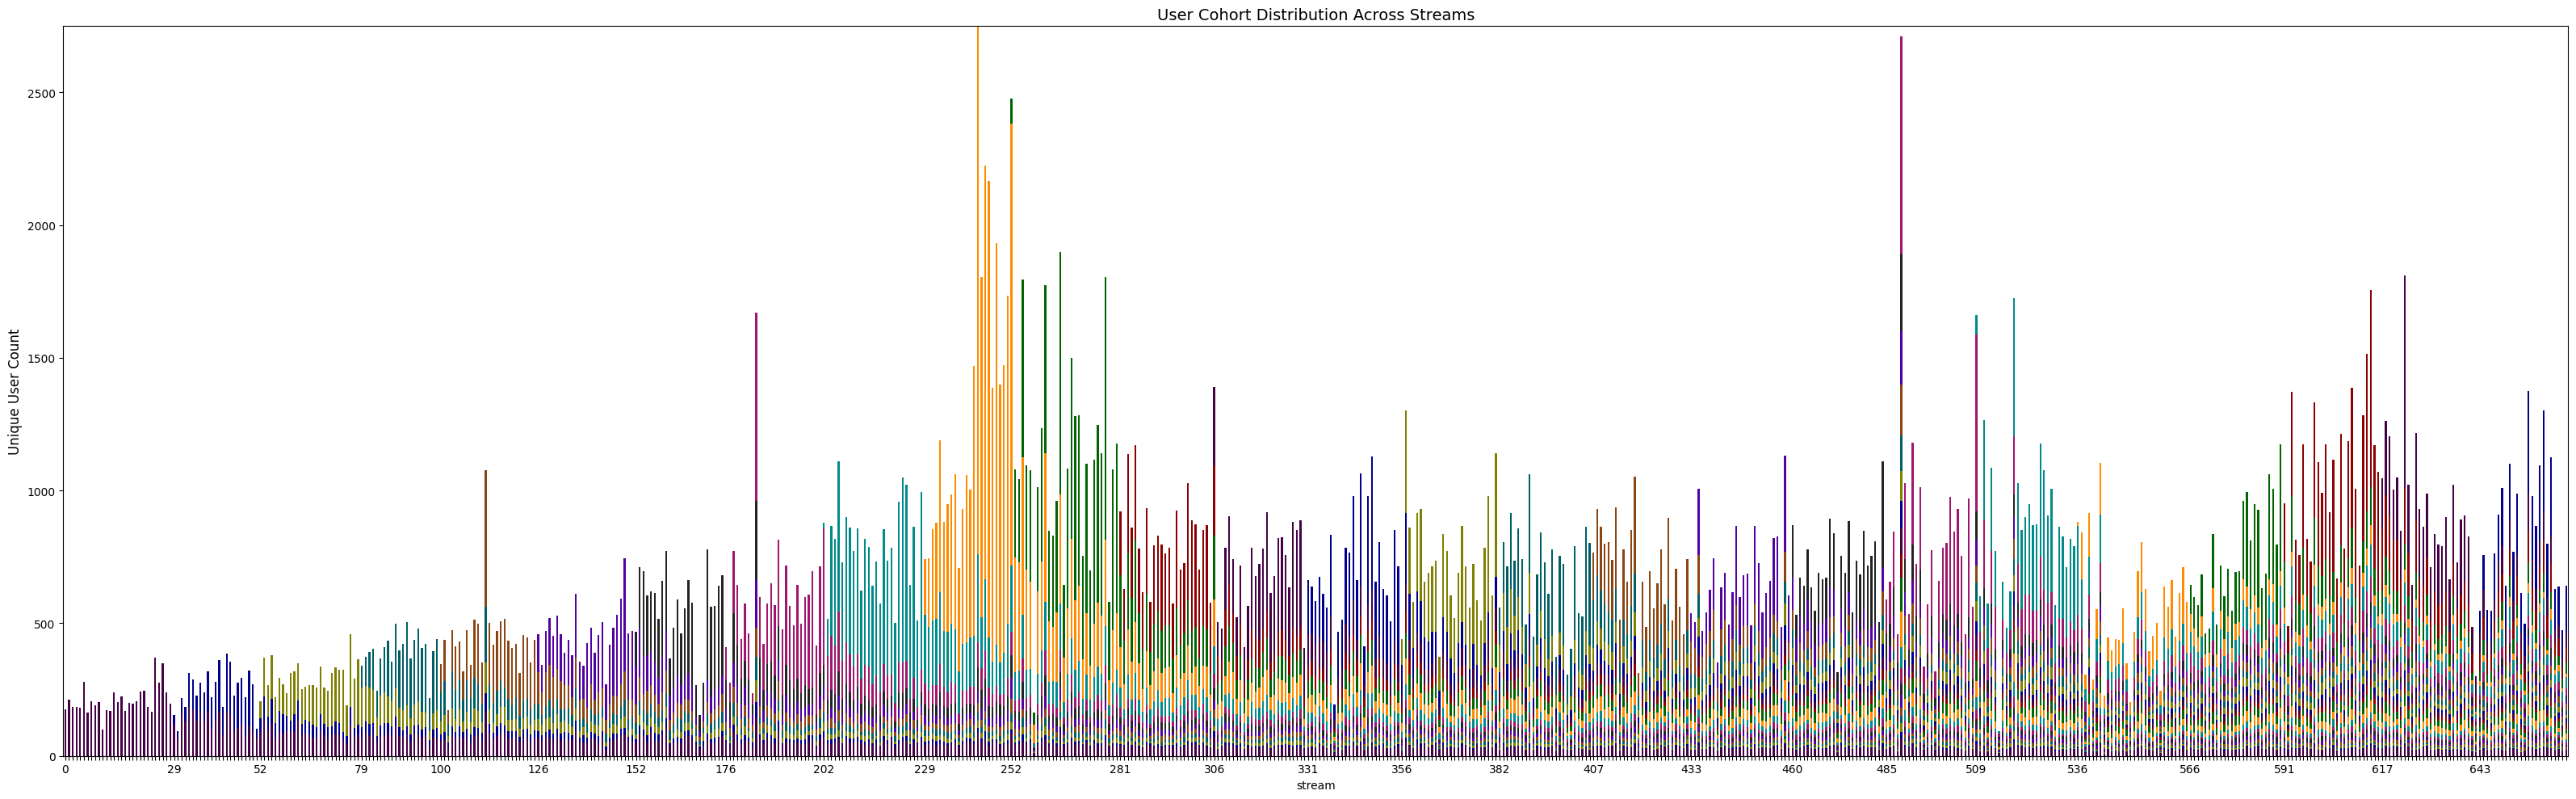

In [10]:
# 1. Define your custom color map
base_color_map = {
    1: '#008B8B',   
    2: '#FF8C00',   
    3: '#006400',   
    4: '#8B0000',   
    5: '#450145',   
    6: '#00008B',   
    7: '#808000',   
    8: "#005F64",   
    9: '#8B4513',   
    10: "#5102a1",  
    11: '#242323',  
    12: "#9F166D"   
}

# 2. Transpose the pivot table so Stream IDs are on the X-axis
plot_data = pivot_df.T
plot_data.columns = plot_data.columns.astype(str)

# 3. Create a list of colors by extracting the month number from each column name (e.g., '2024-05' -> 5)
color_list = [base_color_map[int(col.split('-')[1])] for col in plot_data.columns]

# 4. Plot the chart using the custom color list
ax = plot_data.plot(kind='bar', stacked=True, figsize=(32, 10), color=color_list, legend=False)

# 5. Labels and legend formatting
plt.title('User Cohort Distribution Across Streams', fontsize=14)
# Customize x-axis ticks: only show the month name for the first stream of each month
xticks = range(len(plot_data.index))  # using plot_data because it was transposed
xticklabels = []

# 1. Identify the chronologically first stream ID for every calendar month
# We sort by date, group by month, and pick the first stream ID that appears
data['message_month'] = data['date'].dt.to_period('M')
first_streams_per_month = data.sort_values('date').groupby('message_month')['stream'].first().unique()

# 2. Customize your x-axis ticks using your updated pivot table index
# (Since we transposed in Step 3, pivot_df.T.index contains your Stream IDs)
xticks = range(len(plot_data.index))
xticklabels = []

for stream_id in plot_data.index:
    if stream_id in first_streams_per_month:
        xticklabels.append(str(stream_id))  # Show stream number if it was the first of the month
    else:
        xticklabels.append("")              # Hide the label for clutter-free rendering

ax.set_xticks(xticks)
ax.set_xticklabels(xticklabels, rotation=0)

ax.set_xticks(xticks)
ax.set_xticklabels(xticklabels, rotation=0)
plt.style.use('dark_background')
plt.ylim(0, 2750)
plt.ylabel('Unique User Count', fontsize=12)
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

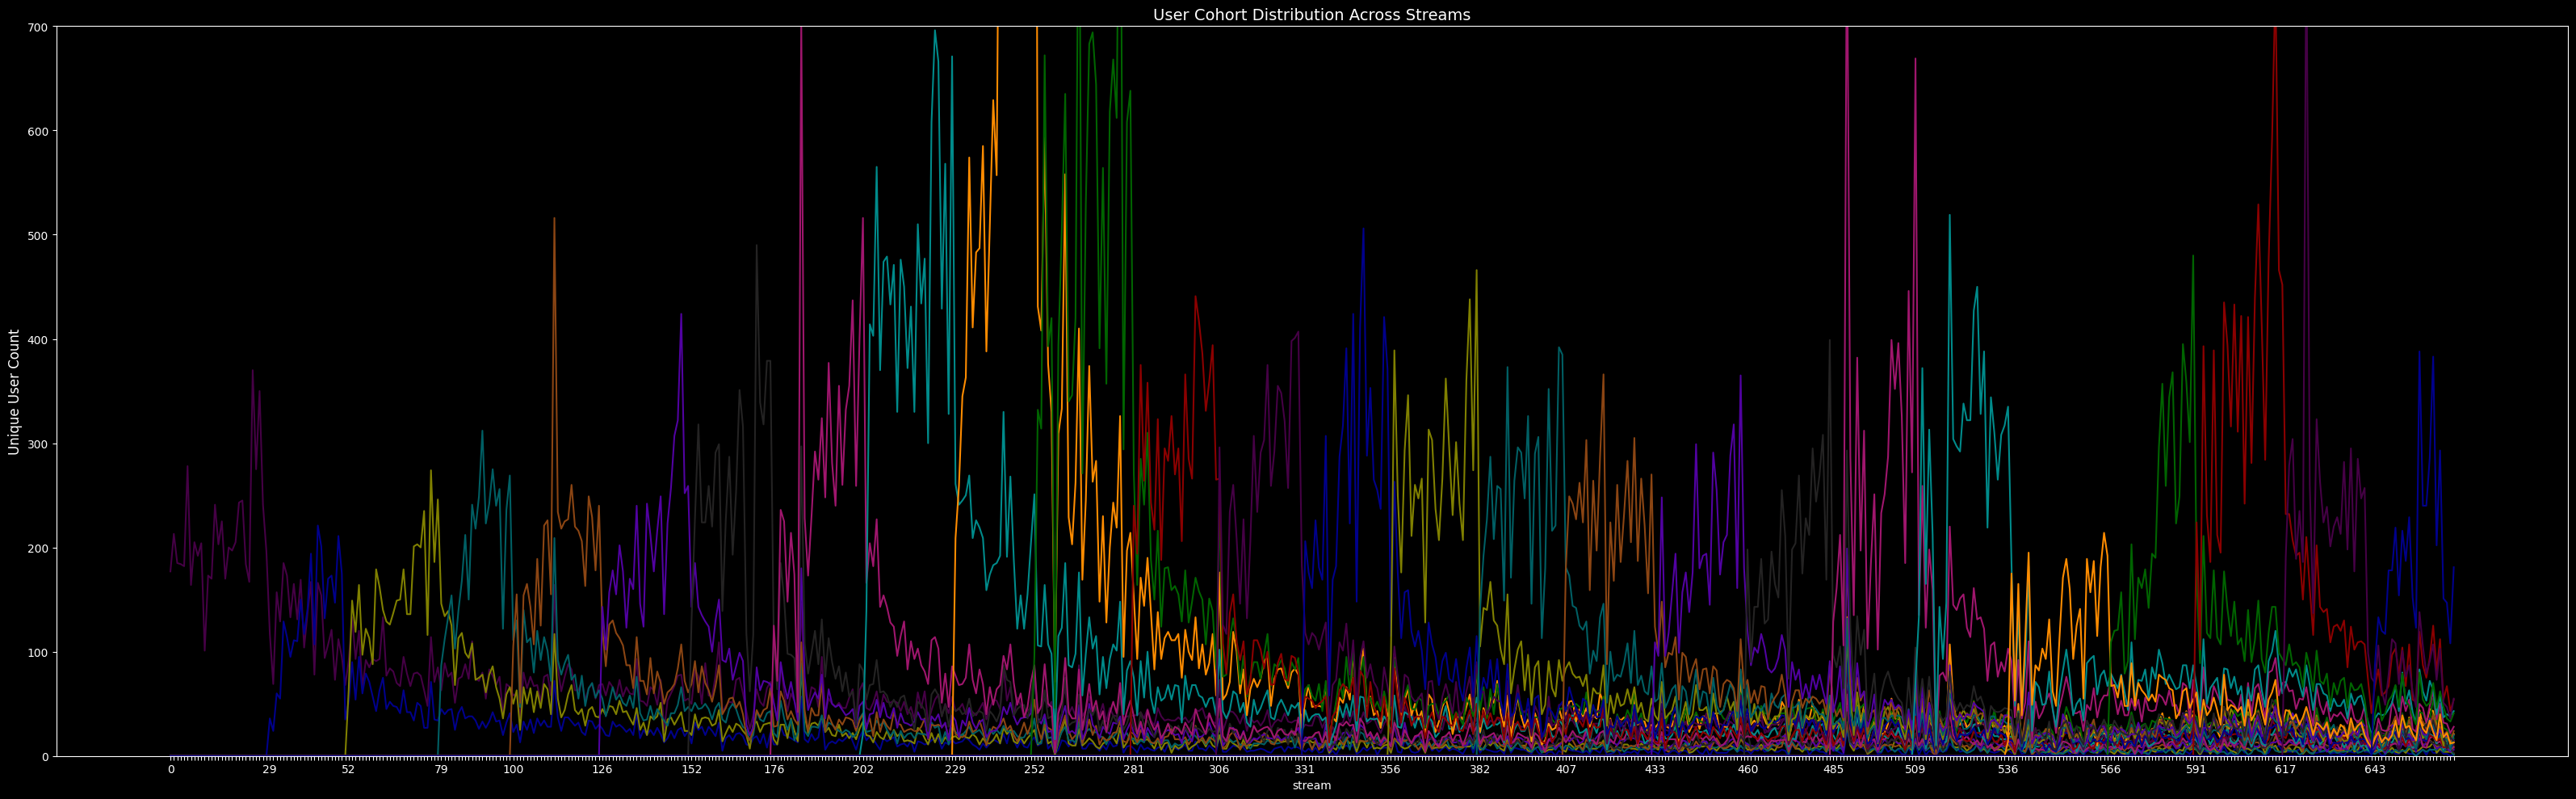

In [11]:
# Create a temporary copy with a string index for the line chart
# This ensures sequential, categorical X-axis spacing to match your custom ticks
plot_data_line = plot_data.copy()
plot_data_line.index = plot_data_line.index.astype(str)

# 4. Plot the chart using kind='line' and the custom color list
# Note: kept stacked=True to match your bar chart behavior. Set to False for individual lines.
ax = plot_data_line.plot(kind='line', stacked=False, figsize=(32, 10), color=color_list, legend=False)

# 5. Labels and formatting
plt.title('User Cohort Distribution Across Streams', fontsize=14)

# Customize x-axis ticks using your existing loop logic
xticks = range(len(plot_data.index))
xticklabels = []

for stream_id in plot_data.index:
    if stream_id in first_streams_per_month:
        xticklabels.append(str(stream_id))  # Show stream number if it was the first of the month
    else:
        xticklabels.append("")              # Hide the label for clutter-free rendering

ax.set_xticks(xticks)
ax.set_xticklabels(xticklabels, rotation=0)

# Note: If you change to stacked=False, remember to remove or lower plt.ylim(0, 2750) 
# as individual lines will have a much lower maximum height than the stacked total.
plt.ylim(0, 700)
plt.ylabel('Unique User Count', fontsize=12)

plt.tight_layout()
plt.show()